In [2]:
#import of the packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import os
from sklearn.linear_model import LinearRegression as lr 

#import from package 'geone'
from geone import img
from geone import grf
import geone.imgplot as imgplt
import geone.customcolors as ccol
import geone.deesseinterface as dsi


#read the simulation methods function file
exec(open('../functions/02_simulation_functions.py').read())
exec(open('../functions/02_kriging_functions.py').read())


%matplotlib inline
%xmode Plain

Exception reporting mode: Plain


In [22]:
path_data_test = '../generated_data_withTrend/'
#path_ti        = '../data/TI/pickle/ti_alt1_2016_2m.pickle'
simu_test_name = sorted(os.listdir(path_data_test))[0]
simu_test_name

'realisation00.pickle'

In [6]:
read_data('../data','TI_Alt2_After_Julien1.tif')

ValueError: could not convert string to int

In [23]:
t = read_data(path_data_test, simu_test_name)

In [13]:
len(data)

7

In [5]:
t = read_data(path_data_test, simu_test_name)

In [6]:
len(t)

7

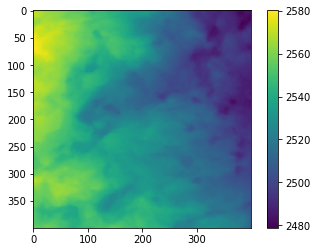

In [24]:
plt.imshow(t[0])
plt.colorbar()

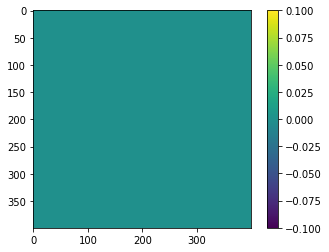

In [25]:
plt.imshow(t[1])
plt.colorbar()

In [26]:
t[2]

array([1335, 1735,  519,  919])

In [27]:
t[3]

,cell_x,cell_y,alt,X,Y
0,1373,519,2560.592773,583222.0,133968.0
1,1373,520,2561.121094,583224.0,133968.0
2,1373,521,2561.689453,583226.0,133968.0
3,1373,522,2562.333496,583228.0,133968.0
4,1373,523,2562.818848,583230.0,133968.0
...,...,...,...,...,...
2468,1734,914,2510.146240,584012.0,134690.0
2469,1734,915,2510.296143,584014.0,134690.0
2470,1734,916,2510.785645,584016.0,134690.0
2471,1734,917,2511.048584,584018.0,134690.0


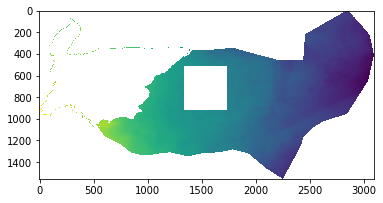

In [28]:
plt.imshow(t[4])

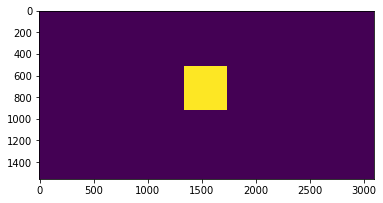

In [29]:
plt.imshow(t[5])

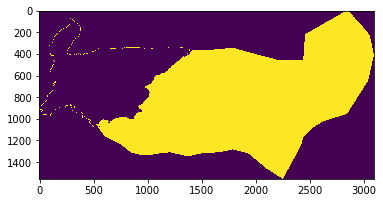

In [30]:
plt.imshow(t[6])

In [31]:
t[6]

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [20]:
#Set the model:
cov_model = gcm.CovModel2D(elem=[
    ('spherical', {'w':380., 'r':[324,228]}),
    ('gaussian', {'w':90., 'r':[564,564]}),
    ('gaussian', {'w':130., 'r':[1000000,1000]}),
    ('gaussian', {'w':20., 'r':[1000000,1800]}),
    ('spherical', {'w':20., 'r':[1000000,1000]})# elementary contribution
                       ], alpha=20, name='model-2D test')

In [21]:
g#Set the function:
cov_fun = cov_model.func()
vario_fun = cov_model.vario_func()

In [29]:
hd_df = t[3]
position = t[2]
hd_df.head()

,cell_x,cell_y,alt,X,Y
0,2621,439,0.007324,583010.0,136474.0
1,2622,439,0.375488,583010.0,136476.0
2,2623,439,0.805420,583010.0,136478.0
3,2624,439,1.311523,583010.0,136480.0
4,2625,440,1.894775,583012.0,136482.0


In [23]:
help(gcm)

Help on module geone.covModel in geone:

NAME
    geone.covModel

DESCRIPTION
    Python module:  'covModel.py'
    author:         Julien Straubhaar
    date:           jan-2018
    
    Definition of classes for covariance / variogram models in 1D, 2D and 3D.

CLASSES
    builtins.object
        CovModel1D
        CovModel2D
        CovModel3D
    
    class CovModel1D(builtins.object)
     |  Defines a covariance model in 1D:
     |      elem:   (sequence of 2-tuple) an entry (t, d) of the sequence
     |                  corresponds to an elementary model with:
     |                      t: (string) the type, could be
     |                         'nugget', 'spherical', 'exponential', 'gaussian',
     |                         'cubic', 'power'
     |                      d: (dict) dictionary of required parameters to be
     |                          passed to the elementary model,
     |                  e.g.
     |                     (t, d) = ('power', {w:2.0, r:1.5, s:1.7})
